# Noise reduction

This notebook demonstrates the noise tools in `nolitisea.noise`:
adding synthetic noise to a clean series, denoising with local
projection or local averaging, and quantifying the improvement with
point-wise, correlation and time-warping metrics.

| # | Function | Purpose |
|---|----------|---------|
| 1 | `add_noise` | Add gaussian / uniform / colored / harmonic / impulse noise |
| 2 | `ghkss` | Local-projection denoising |
| 3 | `compare` | Error and similarity metrics |
| 4 | `lazy` | Local-averaging denoising |

## 1. `add_noise` — add synthetic noise

Add noise to a series with `nolitisea.noise.add_noise.add_noise`.

The input may be 1-D (a single series) or 2-D (one column per variable); every column receives its own independent noise realisation.  Five noise types are supported, and the meaning of `level` depends on the type:

- `"gaussian"` / `"colored"`: noise standard deviation relative to the per-column standard deviation (absolute when `absolute=True`);
- `"uniform"`: half-width of the distribution `[-level*std, +level*std]`;
- `"harmonic"`: scales the sinusoid amplitudes by `level * std`;
- `"impulse"`: unused (use `impulse_prob` and `impulse_amplitude`).

Each type is demonstrated below on a clean Lorenz trajectory.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from nolitisea.generate.lorenz import lorenz
from nolitisea.noise.add_noise import add_noise

# Clean Lorenz trajectory; every column is one scalar time series.
np.random.seed(0)
_, clean = lorenz(length=2000)
t = np.arange(clean.shape[0])
n = 500  # segment shown in the time-series plots

print(f"clean: shape {clean.shape}, per-column std {clean.std(axis=0).round(2)}")

clean: shape (2000, 3), per-column std [7.92 8.99 8.58]


### Gaussian and uniform noise

Both are white (uncorrelated).  With the same `level`, the uniform noise is bounded to `[-level*std, +level*std]` while the Gaussian one has unbounded tails, so at the same level the uniform noise looks slightly smaller.

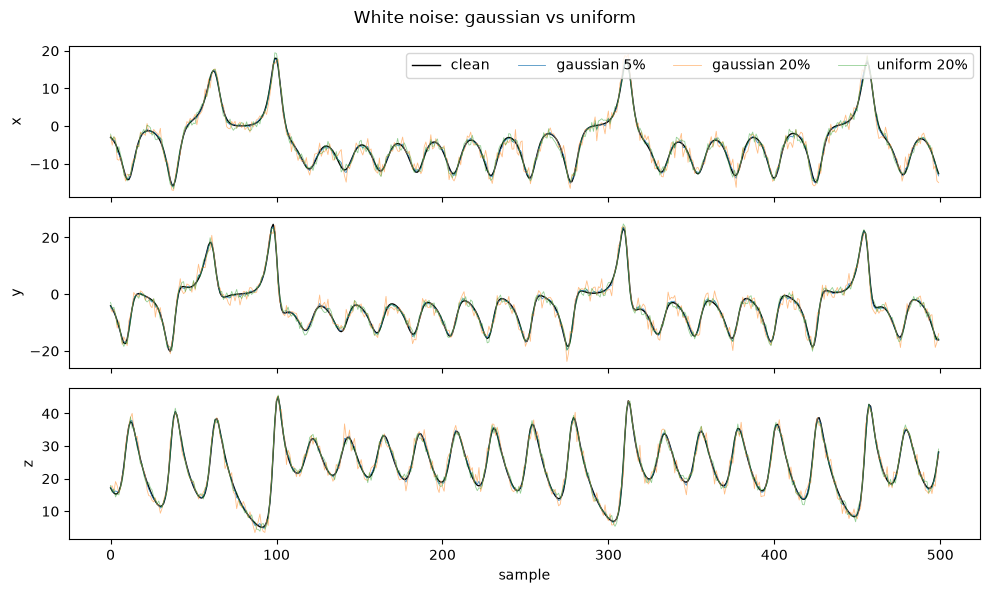

In [2]:
g5 = add_noise(clean, noise_type="gaussian", level=0.05, seed=42)
g20 = add_noise(clean, noise_type="gaussian", level=0.20, seed=42)
u20 = add_noise(clean, noise_type="uniform", level=0.20, seed=42)

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
for j, (ax, name) in enumerate(zip(axes, "xyz")):
    ax.plot(t[:n], clean[:n, j], lw=1.0, color="black", label="clean")
    ax.plot(t[:n], g5[:n, j], lw=0.6, alpha=0.8, label="gaussian 5%")
    ax.plot(t[:n], g20[:n, j], lw=0.6, alpha=0.5, label="gaussian 20%")
    ax.plot(t[:n], u20[:n, j], lw=0.6, alpha=0.5, label="uniform 20%")
    ax.set_ylabel(name)
axes[0].legend(loc="upper right", ncols=4)
axes[-1].set_xlabel("sample")
fig.suptitle("White noise: gaussian vs uniform")

plt.tight_layout()
plt.show()

### Colored noise

`alpha` controls the power-law exponent of the noise spectrum: `alpha=0` gives white, `alpha=1` pink (flicker) and `alpha=2` red (Brownian) noise.  The realisations below are generated on a zero signal with `absolute=True` so the noise itself is visible, together with the periodograms confirming the `1/f^alpha` spectra.

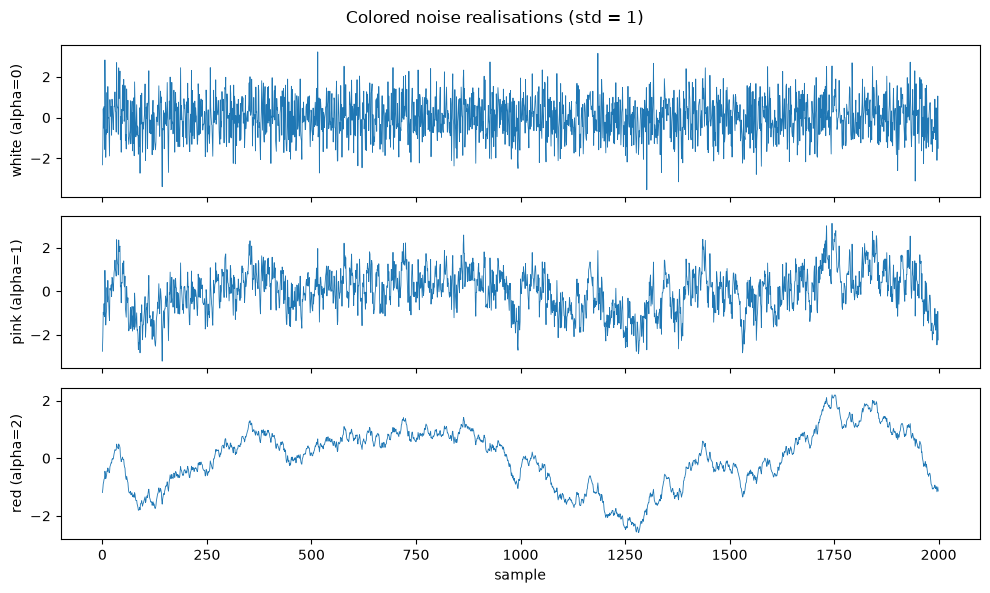

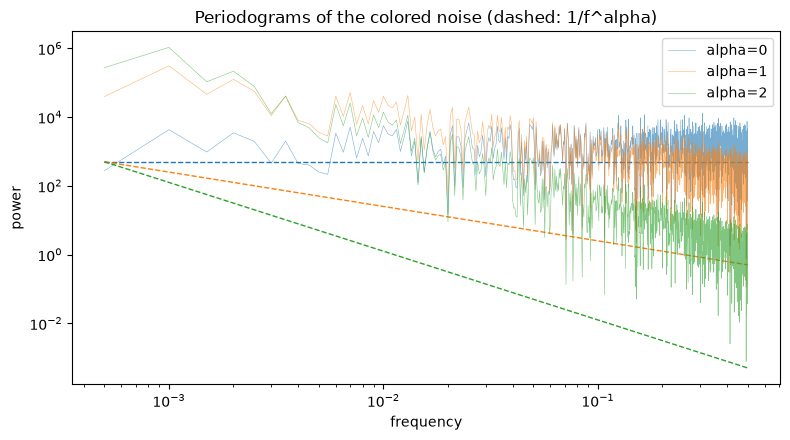

In [3]:
alphas = [0.0, 1.0, 2.0]
labels = ["white (alpha=0)", "pink (alpha=1)", "red (alpha=2)"]

# Realisations on a zero signal, standard deviation 1.
noise_by_alpha = {
    a: add_noise(np.zeros(2000), noise_type="colored", level=1.0,
                 alpha=a, absolute=True, seed=7)
    for a in alphas
}

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
for ax, a, label in zip(axes, alphas, labels):
    ax.plot(t, noise_by_alpha[a], lw=0.6)
    ax.set_ylabel(label)
axes[-1].set_xlabel("sample")
fig.suptitle("Colored noise realisations (std = 1)")

plt.tight_layout()
plt.show()

# Periodograms with reference power-law slopes.
freq = np.fft.rfftfreq(2000)[1:]
fig, ax = plt.subplots(figsize=(8, 4.5))
for a, color in zip(alphas, ["C0", "C1", "C2"]):
    psd = np.abs(np.fft.rfft(noise_by_alpha[a])[1:]) ** 2
    ax.loglog(freq, psd, lw=0.4, alpha=0.6, color=color,
              label=f"alpha={a:.0f}")
    ax.loglog(freq, 5e2 * freq[0] ** a * freq ** (-a), ls="--",
              lw=1.0, color=color)
ax.set_xlabel("frequency")
ax.set_ylabel("power")
ax.set_title("Periodograms of the colored noise (dashed: 1/f^alpha)")
ax.legend()

plt.tight_layout()
plt.show()

### Harmonic and impulse noise

- `"harmonic"` adds a sum of sinusoids with the given `amplitudes`, `frequencies` (cycles per sample) and `phases`; `level` scales the amplitudes by `level * std(signal)`.
- `"impulse"` replaces each sample with probability `impulse_prob` by `+/- impulse_amplitude * std` (bipolar, default) or `+impulse_amplitude * std` ("salt").

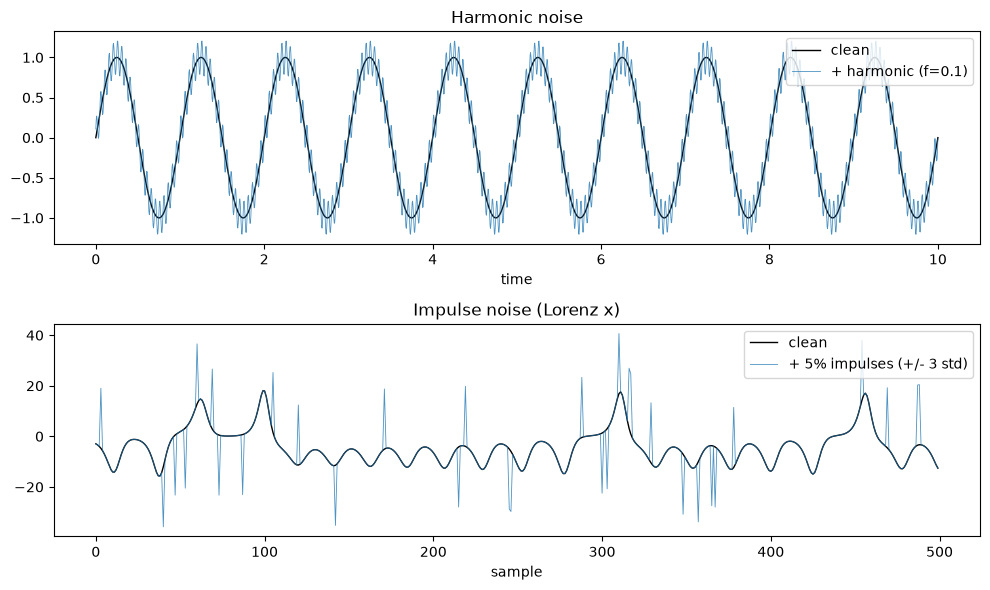

In [4]:
# Harmonic noise on a smooth signal.
tt = np.linspace(0.0, 10.0, 2000)
signal = np.sin(2.0 * np.pi * tt)
harm = add_noise(
    signal, noise_type="harmonic", level=0.3,
    amplitudes=(1.0,), frequencies=(0.1,), seed=3,
)

# Impulse noise on the Lorenz x component.
imp = add_noise(
    clean[:, 0], noise_type="impulse",
    impulse_prob=0.05, impulse_amplitude=3.0, seed=11,
)

fig, axes = plt.subplots(2, 1, figsize=(10, 6))
axes[0].plot(tt, signal, lw=1.0, color="black", label="clean")
axes[0].plot(tt, harm, lw=0.6, alpha=0.8, label="+ harmonic (f=0.1)")
axes[0].set_xlabel("time")
axes[0].set_title("Harmonic noise")
axes[0].legend(loc="upper right")

axes[1].plot(t[:n], clean[:n, 0], lw=1.0, color="black", label="clean")
axes[1].plot(t[:n], imp[:n], lw=0.6, alpha=0.8,
             label="+ 5% impulses (+/- 3 std)")
axes[1].set_xlabel("sample")
axes[1].set_title("Impulse noise (Lorenz x)")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

## 2. `ghkss` — local-projection denoising

Reduce noise with `nolitisea.noise.ghkss.ghkss`, the Grassberger-Hegger-Kantz-Schaffrath-Schreiber local-projection filter.

Each phase-space point is projected onto the `qdim` dominant eigendirections of its metric-weighted neighbourhood covariance; the orthogonal complement is treated as noise.  The input convention is `(n_times, comp)` — one column per component — matching the output of `lorenz` and `add_noise`.

In [5]:
from nolitisea.noise.ghkss import ghkss

# Regenerate the clean trajectory and add 20% Gaussian noise.
np.random.seed(0)
_, clean = lorenz(length=2000)
noisy = add_noise(clean, noise_type='gaussian', level=0.20, seed=42)

# ghkss expects (n_times, comp): pass the noisy trajectory directly.
result = ghkss(noisy, embed=6, delay=1, qdim=3, minn=60, iterations=3)
corrected = result['corrected']  # same shape as noisy

# Quantify the noise reduction.
rms_noisy = np.sqrt(np.mean((noisy - clean) ** 2))
rms_corr = np.sqrt(np.mean((corrected - clean) ** 2))
print(f'RMS error (noisy)    : {rms_noisy:.4f}')
print(f'RMS error (corrected): {rms_corr:.4f}')
print(f'improvement          : {100 * (1 - rms_corr / rms_noisy):.1f}%')
for i, st in enumerate(result['stats']):
    avg = [round(v, 4) for v in st['average_shift']]
    rms = [round(v, 4) for v in st['rms_correction']]
    print(f'  iter {i+1}: avg_shift={avg}, rms_corr={rms}')

RMS error (noisy)    : 1.7067
RMS error (corrected): 0.6941
improvement          : 59.3%
  iter 1: avg_shift=[-0.0025, 0.0005, -0.0001], rms_corr=[0.487, 0.5677, 0.5205]
  iter 2: avg_shift=[-0.0017, -0.0002, -0.001], rms_corr=[0.3407, 0.3898, 0.3674]
  iter 3: avg_shift=[-0.0007, -0.0005, -0.0016], rms_corr=[0.2372, 0.2635, 0.2586]


### Save the results

Write the noisy and corrected trajectories to text files for later analysis.

In [6]:
from pathlib import Path

data_dir = Path('./data')
data_dir.mkdir(parents=True, exist_ok=True)

np.savetxt(data_dir / 'lorenz_noisy.txt', noisy, fmt='%.8f',
           header='Lorenz + 20% Gaussian noise; columns: x y z')
np.savetxt(data_dir / 'lorenz_corrected.txt', corrected, fmt='%.8f',
           header='Lorenz after GHKSS (embed=6, delay=1, qdim=3, '
                   'minn=60, iterations=3); columns: x y z')

print(f'saved {len(noisy)} samples to {data_dir}')

saved 2000 samples to data


### Time-series comparison

Clean, noisy and corrected signals overlaid for each component:

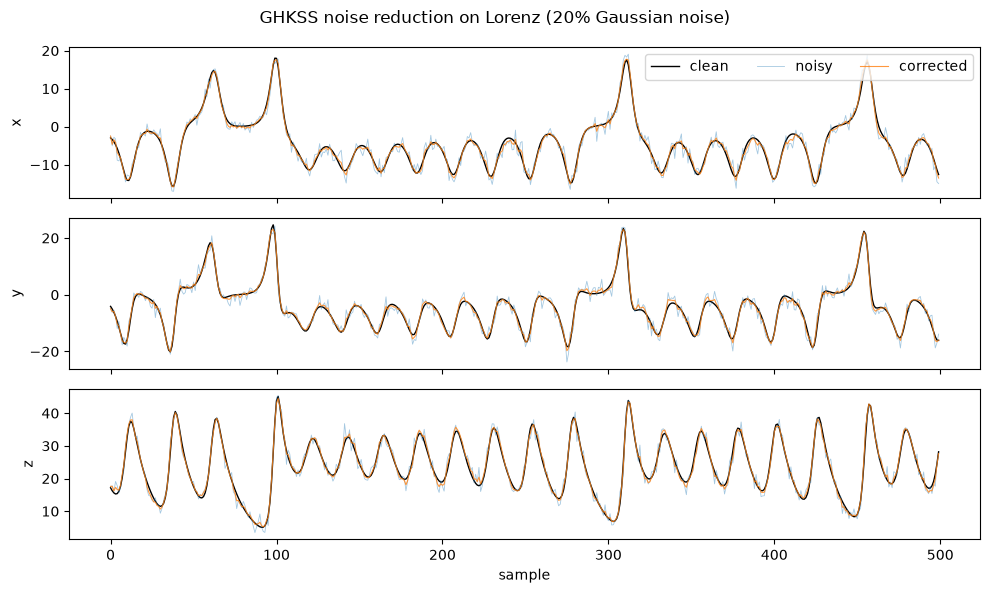

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
for j, (ax, name) in enumerate(zip(axes, 'xyz')):
    ax.plot(t[:n], clean[:n, j], lw=1.0, color='black', label='clean')
    ax.plot(t[:n], noisy[:n, j], lw=0.6, alpha=0.4, label='noisy')
    ax.plot(t[:n], corrected[:n, j], lw=0.8, alpha=0.8, label='corrected')
    ax.set_ylabel(name)
axes[0].legend(loc='upper right', ncols=3)
axes[-1].set_xlabel('sample')
fig.suptitle('GHKSS noise reduction on Lorenz (20% Gaussian noise)')

plt.tight_layout()
plt.show()

### 3-D attractor comparison

The same data in phase space.  The noisy trajectory is scattered off the attractor; after GHKSS the trajectory returns close to the original manifold.

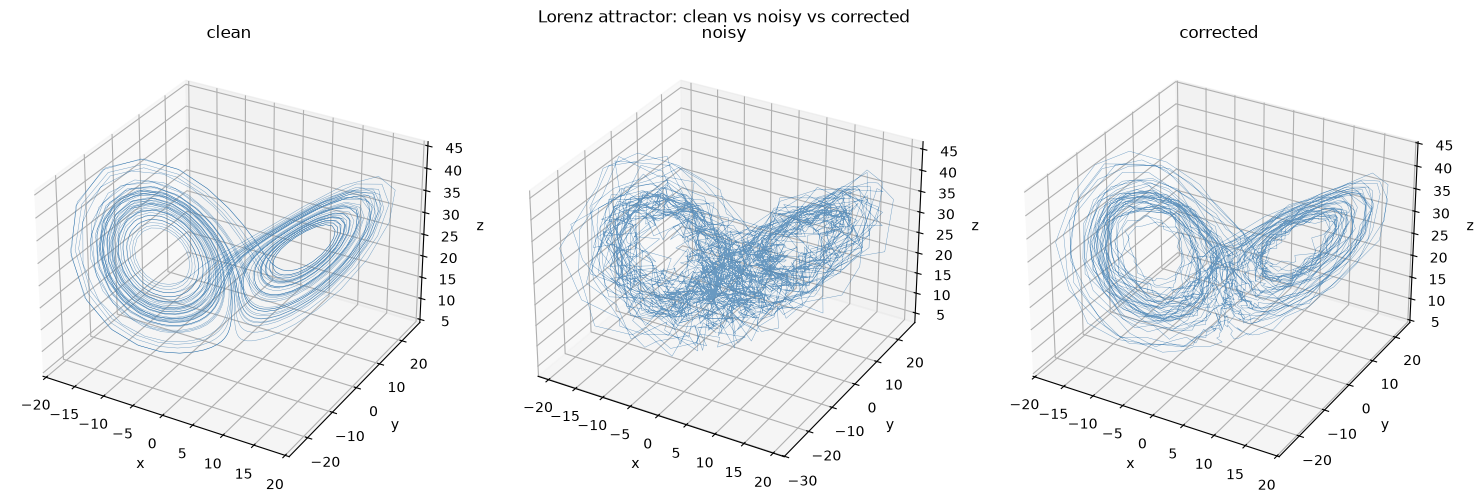

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5),
                         subplot_kw={'projection': '3d'})
for ax, data, title in zip(
    axes, [clean, noisy, corrected],
    ['clean', 'noisy', 'corrected'],
):
    ax.plot(data[:, 0], data[:, 1], data[:, 2],
            lw=0.3, color='steelblue', alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
fig.suptitle('Lorenz attractor: clean vs noisy vs corrected')

plt.tight_layout()
plt.show()

## 3. `compare` — similarity and error metrics

Quantify how close the noisy and the GHKSS-corrected signals are
to the clean ground truth with `nolitisea.noise.compare`.  The
module provides three families of 1-D metrics:

* **point-wise errors**: `mae`, `mse`, `rmse`, `nrmse_ptp`,
  `r2_score`;
* **shape / correlation**: `pearson_corr`, `max_cross_correlation`,
  `cosine_similarity`;
* **time-warped shape**: `dtw_distance`.

Each function takes a reference series `x` (ground truth) and a
test series `y`; lower error / higher correlation means better
agreement.  We reuse the `clean`, `noisy` and `corrected` Lorenz
arrays produced in the GHKSS section above (column 0 = x).

In [9]:
from nolitisea.noise.compare import (
    cosine_similarity,
    dtw_distance,
    mae,
    max_cross_correlation,
    mse,
    nrmse_ptp,
    pearson_corr,
    r2_score,
    rmse,
)

# Ground-truth / test pairs on the Lorenz x component.
pairs = {
    "noisy vs clean":     (clean[:, 0], noisy[:, 0]),
    "corrected vs clean": (clean[:, 0], corrected[:, 0]),
}
print(f"series length: {clean.shape[0]}")

series length: 2000


### Point-wise error metrics

`mae`, `mse`, `rmse` accumulate the residual `x - y`; `nrmse_ptp`
normalises the RMSE by the peak-to-peak range of the reference
(so it is scale-free), and `r2_score` is the coefficient of
determination (`1` is perfect, `0` equals predicting the mean,
negative means worse than the mean).  All five return `np.nan`
when the reference is constant.

In [10]:
rows = []
for name, (x, y) in pairs.items():
    rows.append([
        name, mae(x, y), mse(x, y), rmse(x, y),
        nrmse_ptp(x, y), r2_score(x, y),
    ])

header = "pair                      MAE       MSE      RMSE     NRMSE      R2"
print(header)
for name, m, s, r, n, r2 in rows:
    print(f"{name:<22}{m:9.4f}{s:9.4f}{r:9.4f}{n:9.4f}{r2:8.4f}")

pair                      MAE       MSE      RMSE     NRMSE      R2
noisy vs clean           1.2593   2.5277   1.5899   0.0443  0.9597
corrected vs clean       0.4820   0.3803   0.6167   0.0172  0.9939


After GHKSS denoising every point-wise error drops substantially
and `R²` moves closer to 1, confirming the correction recovers
the attractor trajectory.

### Correlation and shape similarity

* `pearson_corr(x, y)` returns `(r, p_value)` for the linear
  correlation;
* `max_cross_correlation(x, y, max_lag=...)` returns
  `(max_r, best_lag)`, scanning lags to find the best alignment;
* `cosine_similarity(x, y)` measures directional agreement of the
  two vectors, ignoring magnitude.

In [11]:
header = "pair                  pearson r     p-value   maxxcc r   lag   cosine"
print(header)
for name, (x, y) in pairs.items():
    r, p = pearson_corr(x, y)
    mr, lag = max_cross_correlation(x, y)
    cos = cosine_similarity(x, y)
    print(f"{name:<22}{r:11.4f}{p:12.2e}{mr:11.4f}{lag:6d}{cos:9.4f}")

pair                  pearson r     p-value   maxxcc r   lag   cosine
noisy vs clean             0.9803    0.00e+00     0.9803     0   0.9804
corrected vs clean         0.9970    0.00e+00     0.9970     0   0.9970


### Detecting a time shift with `max_cross_correlation`

A pure lag between two otherwise identical series leaves the
zero-lag Pearson `r` below 1, but `max_cross_correlation`
recovers `r ≈ 1` and reports the shift in samples.

In [12]:
# Shift the clean x component by 5 samples and compare.
x_ref = clean[:, 0]
x_shift = np.roll(x_ref, shift=5)

r0, _ = pearson_corr(x_ref, x_shift)
mr, lag = max_cross_correlation(x_ref, x_shift)
print(f"pearson (zero-lag): {r0:.4f}")
print(f"max cross-corr:     r={mr:.4f}  lag={lag}  (true shift=5)")

pearson (zero-lag): 0.7419
max cross-corr:     r=0.9992  lag=-5  (true shift=5)


### Dynamic Time Warping distance

`dtw_distance` measures shape similarity under non-linear time
warping: it is invariant to local stretching/compression of the
time axis, unlike the point-wise errors above.  The cost is
O(n·m), so we evaluate it on a 500-sample window.

In [13]:
window = 500
print(f"DTW distance over the first {window} samples:")
for name, (x, y) in pairs.items():
    d = dtw_distance(x[:window], y[:window])
    print(f"  {name:<22}{d:10.3f}")

DTW distance over the first 500 samples:
  noisy vs clean           501.856
  corrected vs clean       187.861


## 4. `lazy` — local-averaging denoising

Reduce noise with `nolitisea.noise.lazy.lazy`, the simple local
phase-space averaging filter (Schreiber 1993; Kantz & Schreiber 2004).

Every point is replaced by the average of the centre coordinates of all
embedded neighbours within radius `r`:

* `dim`, `delay` — embedding of the scalar series;
* `r` — neighbourhood radius (metric-dependent; `r=0` means "do
  nothing");
* `metric` — `"chebyshev"` (default), `"euclidean"` or `"cityblock"`;
* `repeat` — number of passes; after each pass `r` is replaced by the
  RMS correction of that pass, and the iteration stops as soon as the
  series stops changing.

`lazy` operates on a single scalar series, so we feed it the noisy
Lorenz x component from the GHKSS section above.


In [14]:
from nolitisea.noise.lazy import lazy

# Noisy Lorenz x component (20% Gaussian noise, section 2).
x_noisy = noisy[:, 0]
x_clean = clean[:, 0]

x_lazy = lazy(x_noisy, dim=3, delay=1, r=4.0, metric="chebyshev", repeat=2)

rms_noisy = np.sqrt(np.mean((x_noisy - x_clean) ** 2))
rms_lazy = np.sqrt(np.mean((x_lazy - x_clean) ** 2))
rms_ghkss = np.sqrt(np.mean((corrected[:, 0] - x_clean) ** 2))
print(f"RMS error (noisy) : {rms_noisy:.4f}")
print(f"RMS error (lazy)  : {rms_lazy:.4f}")
print(f"RMS error (GHKSS) : {rms_ghkss:.4f}   (section 2, for reference)")
print(f"improvement       : {100 * (1 - rms_lazy / rms_noisy):.1f}%")


RMS error (noisy) : 1.5899
RMS error (lazy)  : 0.9156
RMS error (GHKSS) : 0.6167   (section 2, for reference)
improvement       : 42.4%


### Effect of the neighbourhood radius

`r` trades noise suppression against signal distortion: too small and
each neighbourhood contains only the point itself (no filtering), too
large and the averaging smears the dynamics.  Scanning the radius
against the RMS error to the clean series reveals a clear optimum.


r = 0.5: RMS = 1.5859
r = 1.0: RMS = 1.5357
r = 2.0: RMS = 1.2794
r = 3.0: RMS = 1.0303
r = 4.0: RMS = 0.9156
r = 5.0: RMS = 0.9417
r = 6.0: RMS = 1.0511


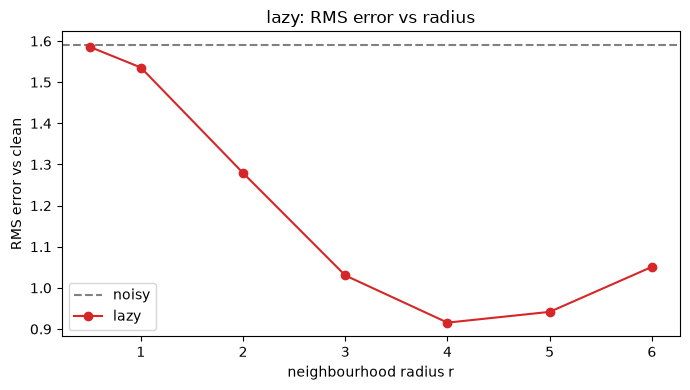

In [15]:
radii = [0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
errors = []
for r in radii:
    y = lazy(x_noisy, dim=3, delay=1, r=r, repeat=2)
    errors.append(np.sqrt(np.mean((y - x_clean) ** 2)))
    print(f"r = {r:.1f}: RMS = {errors[-1]:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.axhline(rms_noisy, color="gray", linestyle="--", label="noisy")
ax.plot(radii, errors, "o-", color="tab:red", label="lazy")
ax.set_xlabel("neighbourhood radius r")
ax.set_ylabel("RMS error vs clean")
ax.set_title("lazy: RMS error vs radius")
ax.legend()
plt.tight_layout()
plt.show()


### Time series and phase space

The corrected segment tracks the clean trajectory much closer than the
noisy one.  In the delay-coordinate phase portrait the noise cloud
shrinks towards the limbs of the Lorenz attractor.  As expected, the
simple averaging scheme improves the RMS error by roughly 40%, still
clearly behind the local-projection filter GHKSS from section 2.


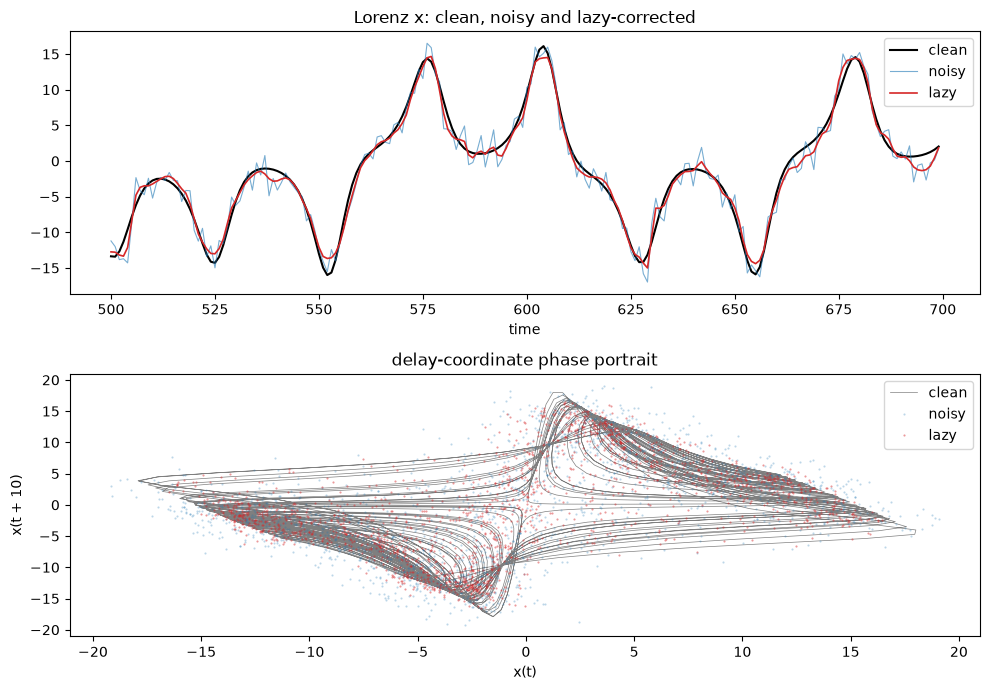

In [16]:
seg = slice(500, 700)  # segment shown in the time-series plot

fig, axes = plt.subplots(2, 1, figsize=(10, 7))
axes[0].plot(t[seg], x_clean[seg], color="black", lw=1.5, label="clean")
axes[0].plot(t[seg], x_noisy[seg], color="tab:blue", lw=0.8, alpha=0.6, label="noisy")
axes[0].plot(t[seg], x_lazy[seg], color="tab:red", lw=1.2, label="lazy")
axes[0].set_xlabel("time")
axes[0].set_title("Lorenz x: clean, noisy and lazy-corrected")
axes[0].legend()

# Delay-coordinate phase portrait (x(t), x(t + 10)).
d = 10
axes[1].plot(x_clean[:-d], x_clean[d:], color="black", lw=0.5, alpha=0.5, label="clean")
axes[1].plot(x_noisy[:-d], x_noisy[d:], ".", color="tab:blue", ms=1, alpha=0.3, label="noisy")
axes[1].plot(x_lazy[:-d], x_lazy[d:], ".", color="tab:red", ms=1, alpha=0.5, label="lazy")
axes[1].set_xlabel("x(t)")
axes[1].set_ylabel("x(t + 10)")
axes[1].set_title("delay-coordinate phase portrait")
axes[1].legend()

plt.tight_layout()
plt.show()


## Summary

The `nolitisea.noise` module covers the full noise-handling pipeline:

- **Noise injection**: `add_noise` supports five noise types (gaussian, uniform, colored, harmonic, impulse) with per-column independent realisations.
- **Denoising**: `ghkss` (local projection onto the dominant eigendirections) and `lazy` (local phase-space averaging) recover the clean trajectory from a noisy signal.
- **Quantitative comparison**: `compare` provides point-wise errors (`mae`, `mse`, `rmse`, `nrmse_ptp`, `r2_score`), shape / correlation metrics (`pearson_corr`, `max_cross_correlation`, `cosine_similarity`), and time-warped distance (`dtw_distance`).

Together these functions let you synthetically corrupt a known trajectory, filter it, and measure how much of the original dynamics was recovered.